## Project 3 Report

### Introduction

RUNX1 is a transcription factor that is important for development and differentiation. RUNX1 plays key roles in tumor suppressor and oncogene in various cancers, including breast cancer. RUNX1 is involved in organizing chromatin at specific genomic sites and regulating gene expression programs, such as those tied to the extracellular matrix and nuclear structure. Chromatin structure, specifically the formation and maintenance to topilogically associating domains (TADs) and local chromatin contacts affects the accessibility of regulatory DNA elements and thus controls the gene expression relevant to cancer progression and suppression. 

The study was performed to elucidate the mechanism by which RUNX1 affects the chromatin architecture and gene expression in breast cancer. This was done by determining whether RUNZ1 acts as an architectural protein influencing higher-order chromatin organization and how its depletion affects genome topology and gene networks crucial for cancer biology. Having a better understanding of RUNX1 could provide new approaches for diagnosis or therapy. 

To map the genome-wide chromatin interactions, Hi-C sequencing was used, providing a 3D view of chromatin organization. This reveals the architectural changes after RUNX1 knockdown. To determine RUNX1 binding sites across the genome, ChIP-sequencing was used. RNA-sequencing was used to profile the changes in gene expression upon RUNX1 depletion, pinpointing the gene networks that RUNX1 regulates. The integration of all the techniques mentioned above allows the researchers to parse the complex relationship between the genome structure and gene output, providing an understanding of the gene regulatory network and therapeutic target for breast cancer. 


### Methods

##### Quality Control, Genome indexing and alignment
The samples were obtained from the NCBI GEO under GEO accession number GSE75070. The initial single-end reads generated from two biological replicates of ChIP-sequencing experiment, which investigated the binding sites of RUNX1 across the genome, underwnt quality assessment using FastQC v0.12.1. The sequencing adpaters and low-quality reads were removed with Trimmomatic v0.40 using default parameters. The human reference genome index was built using Bowtie2 v2.5.4 with default parameters. The trimmed reads were aligned to the indexed reference genome using Bowtie2. The resulting sequence alignment map (SAM) files were converted to binary alignment map (BAM) format, sorted, and indexed using Samtools v1.22 with default parameters. The alignment statistics were calculated for each BAM file using Samtools flagstat v1.22. A comprehensive quality control report was generated by aggregating the outputs from FastQC, Trimmomatic, and Samtools flagstat using MultiQC v1.32. 


##### Read Coverage and Correlation Analysis
The read coverage was calculated across the genome and normalized bigWig files were generated for each sample using the deepTools bamcoverage utility v3.5.6. The similarity between the bigWig files was quantified by calculating the correlation coefficient using deepTools multiBigwigsummary v3.5.6 with default parameters. A correlation heat map was generated using deepTools plotCorrelation utility to visually assess the quality of the replicates and the difference between the IP and INPUT samples. A BED file containing the transcription start sites and termination sites coordinates for all hg38 genes was obtained from the UCSC Table Browser. A scaling regions with 2000 bp padding upstream and downstream was done using deepTools computeMatrix utility to compute the average read coverage of the IP samples relative to the gene body. The resulting metrix was used to visualized the signal intensity plot of IP samples using deepTools plotProfile utility. 

##### Peak calling and Annotation 
Peak calling was performed on the paired IP and INPUT samples for each replicates using HOMER v5.1. A tag directory was created for all BAM files using the makeTagDirectory utility of HOMER v45.1 and the findPeaks utility was run with the -style factor flag parameter to identify the enriched regions in the IP samples relative to their corresponding INPUT controls. The resulting peak files were converted to BED formating using HOMER pos2bed.pl utility with default parameters. A single set of reproducible peaks was generated by taking the intersection of the peaks called from both replicates using the intersect utility of BEDtools v2.31.1. The reproducible peak set was filtered to exclide any overlaps with the ENCODE blacklist regions (hg38) using BEDtools intersect utility with default parameters to removed the signal-artifact regions. The final set of reproducible, filtered peaks was annotated to their nearest genomic features using HOMER annotatePeaks.pl utility with default parameters, providing the reference genome and the GTF files for annotations. 

##### Downstream Analysis
Motif enrichment analysis was performed on the reproducible and fitlered peak set using HOMER findMotifsGenome.pl utility with default parameters to identify the potential de novo and known binding motifs enriched within the binding sites.



![DAG](flowchart.png)



Figure 1. DAG of the pipeline generated from nextflow.

### Quality Control Evaluation

The total number of reads mapped in all samples ranges from 10 million to 28 million reads. INPUT_rep2 has only 10 million reads mapped, while the other three samples (INPUT_rep1, IP_rep1, and IP_rep2) have 27 to 28 million reads mapped to the reference genome.All samples passed the sequence quality and per sequence quality scores with a Phred score of over 30, per base N content of near zero percent, and a sequence length distribution of a single length of 101 bp. All four samples passed the quality control for adapter content; however, the plot shows that adapter sequences begin to appear noticeably after the 60 bp mark, with some approaching or exceeding the 2 percent threshold toward the end of the read.The per base sequence content was flagged as a warning by FastQC for the two IP replicates and failed the two INPUT replicates. Furthermore, the two INPUT replicates failed the per sequence GC content check; however, the two IP replicates show a roughly normal distribution for per sequence GC content. The two IP sample replicates failed the overrepresented sequences check by sample (IP_rep1 with about 2.10 percent of total sequences and IP_rep2 with about 3.13 percent of total sequences). Additionally, both IP replicates failed the sequence duplication levels check.

Based on the MultiQC report, I believe this experiment was of high quality and is suitable for downstream analysis. Trimmomatic was used to trim out the adapter sequences and successfully removed the low-quality and adapter sequences with a minimal loss of total reads. Three of the four samples have about 28 million reads, which is sufficient for a transcription factor ChIP-sequencing analysis. However, the INPUT_rep2 sample has only about 10 million reads, which is significantly lower than the other three. This could be problematic because the INPUT samples are used to model the background noise for peak calling, specifically for IP_rep2. An inaccurate model of the background can cause the peak caller to miss true peaks, and a lack of coverage in certain regions of the INPUT could lead to false enrichment calls.


### Signal Coverage Plot

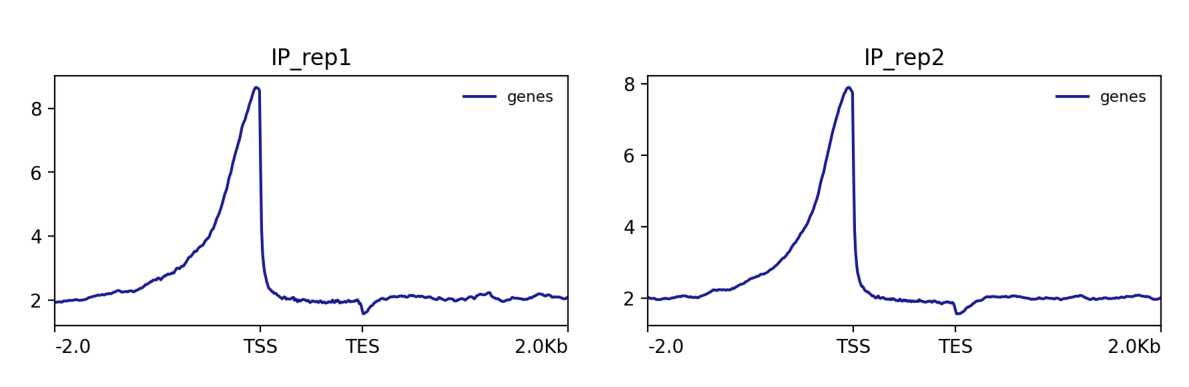

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load images
img1 = mpimg.imread("/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/IP_rep1_signal_coverage.png")
img2 = mpimg.imread("/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/IP_rep2_signal_coverage.png")

# Create a figure with 2 subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Display first image
axs[0].imshow(img1)
axs[0].axis('off')  # remove axes
# axs[0].set_title("IP Replicate 1")

# Display second image
axs[1].imshow(img2)
axs[1].axis('off')  # remove axes
# axs[1].set_title("IP Replicate 2")

plt.tight_layout()
plt.show()


Figure 2. Signal coverage for IP sample replicate 1 and replicate 2.

The signal coverage plot of the two IP replicates representsthe average ChIP-sequencing signal intensity for the factor of interest across a composite reference region encompassing all genes in the hg38 genome. The x-axis represents the genomic position relative to the gene structure, where -2.0Kb is 2000 bases upstream of the transcription start site (TSS) and +2.0Kb is 2000 bases downstream of the transcription end site (TES). The Y-axis represents the mean read coverage, or the signal intensity across the gene regions and the 2Kb upstream and downstream flanking regions. The signal coverage plot is used to answer whether RUNX1 acts as a directly transcriptional regulator and whether it is functioning primarily at the gene promoters to control the transcription initiation. 

The plot shows a high, sharp signal centered at the TSS, with the signal approaching 8 to 9 units. Since, the TSS marks the beginning of a gene and it is the core of the promoter regionm, the binding patter is highly a characteristic of a general transcription factors or sequence-specific transcription factors whose primary role is to initiate or regulate the first step of gene transcription. The signal drops drastically to the background level of about 2 units past the TSS and across the entire gene body. This suggests the factor is not a chromatin protein that coats the entire gene, nor it is a factor that primarily binds to distal enhancers or intragenic features like insulators or transcription termination sites. The slight dip in signal coverage observed at the TES suggests that there is a minor disruption or a lower factor presence in regions involved in the transciption termination. 




### Motif Finding

![knownres](results/knownresults.png)

Figure 3. Top 20 results from the knownresults output from HOMER findMotifsGenome utility.

The motif enrichment analysis shows that the top three motifs belong to RUNX with very high statistical significance, specifically the P-values and log P-values of zero, indicating that the enrichment is not due to chance. The enrichment for the top result has the target sequences with the motif at 26.65 percent, which is higher than the background sequences with the motif at 5.28 percent, demonstrating that the RUNX1 binding motif is the dominant sequence underlying the identified genomic regions. Additionally, the motif enrichment analysis has shown that there are factors other than RUNX1, suggesting that RUNX1 does not operate alone. 
YY1 is a multi-functional transcription factor involved in the looping, the activation, and the repression of chromatin. The significant enrichment of the YY1 motif suggests that RUNX1 binding sites are often located within chromatin interaction hubs or complex regulatory elements that rely on YY1 for proper function. The Forkhead (FOXA) motifs are also highly enriched. FOXA1 specifically, is a crucial pioneer factor and transcription regulator in breast cancer, as it has the ability to bind to and initiate the opening of chromatin and acts as a transcription regulator. Its co-enrichment with RUNX1 suggests that the two genes collaborate in gene regulation or that RUNX1 binds to regions opened up by FOXA motifs.

### Overlap CHIP-seq results with the original RNA-seq data

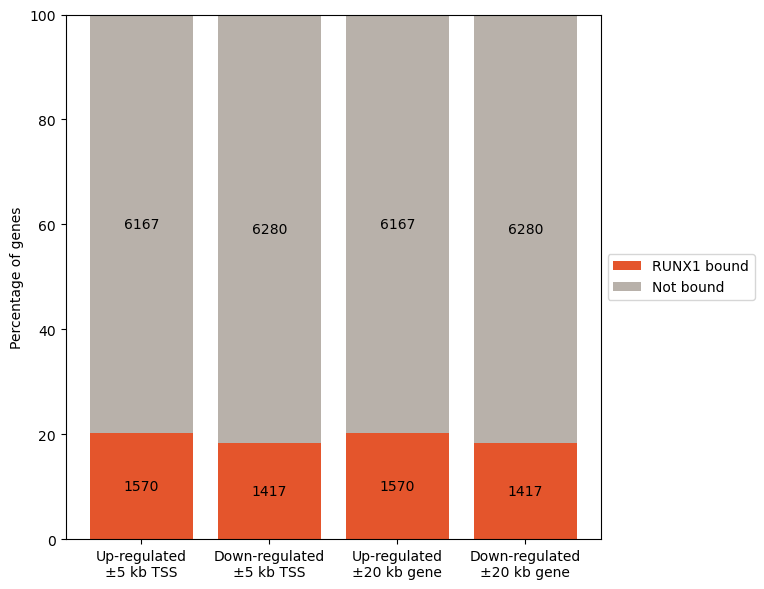

In [2]:
#reproducing figure 2 F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load RNA-seq and annotated peaks
rna = pd.read_csv('/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/GSE75070_MCF7_shRUNX1_shNS_RNAseq_log2_foldchange.txt', sep='\t')
peaks = pd.read_csv('/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/annotated_peaks.txt', sep='\t', low_memory=False)

# Clean gene names
peaks['Gene Name'] = peaks['Gene Name'].astype(str)
rna['genename'] = rna['genename'].astype(str)

# Identify RUNX1-bound genes
genes_5kb = set(peaks['Gene Name'])     # Homer annotatePeaks with ±5kb TSS
genes_20kb = set(peaks['Gene Name'])    # If you also have ±20kb annotation file, load separately;
                                        # if not, this placeholder uses same file.


# Determine up- and down-regulated genes
rna = rna.dropna(subset=['log2FoldChange'])
rna['regulation'] = np.where(rna['log2FoldChange'] > 0, 'up', 'down')

# Build container for plotting
def compute_counts(bound_genes, label):
    up_all = rna[rna['regulation'] == "up"]
    down_all = rna[rna['regulation'] == "down"]

    up_bound = up_all[up_all['genename'].isin(bound_genes)]
    down_bound = down_all[down_all['genename'].isin(bound_genes)]

    return {
        'window': label,
        'up_bound': len(up_bound),
        'up_not': len(up_all) - len(up_bound),
        'down_bound': len(down_bound),
        'down_not': len(down_all) - len(down_bound)
    }

counts_5kb = compute_counts(genes_5kb, "±5 kb TSS")
counts_20kb = compute_counts(genes_20kb, "±20 kb whole gene")

df = pd.DataFrame([counts_5kb, counts_20kb])

# Plot
fig, ax = plt.subplots(figsize=(8,6))

categories = ["Up-regulated", "Down-regulated"]
windows = ["±5 kb TSS", "±20 kb whole gene"]

# Values for stacked bars
bound_vals = [
    df.loc[0, 'up_bound'], df.loc[0, 'down_bound'],
    df.loc[1, 'up_bound'], df.loc[1, 'down_bound']
]
not_vals = [
    df.loc[0, 'up_not'], df.loc[0, 'down_not'],
    df.loc[1, 'up_not'], df.loc[1, 'down_not']
]

x = np.arange(4)

ax.bar(x, np.array(bound_vals) / (np.array(bound_vals) + np.array(not_vals)) * 100,
       label="RUNX1 bound", color="#e4552c")
ax.bar(x, np.array(not_vals) / (np.array(bound_vals) + np.array(not_vals)) * 100,
       bottom=np.array(bound_vals) / (np.array(bound_vals) + np.array(not_vals)) * 100,
       label="Not bound", color="#b8b1aa")

# Add numbers inside bars
total_vals = np.array(bound_vals) + np.array(not_vals)
for i in range(4):
    ax.text(i, (bound_vals[i]/total_vals[i])*100/2,
            str(bound_vals[i]), ha="center", va="center", color="black")
    ax.text(i, (bound_vals[i]/total_vals[i])*100 + (not_vals[i]/total_vals[i])*100/2,
            str(not_vals[i]), ha="center", va="center", color="black")

ax.set_xticks(x)
ax.set_xticklabels([
    "Up-regulated\n±5 kb TSS", "Down-regulated\n±5 kb TSS",
    "Up-regulated\n±20 kb gene", "Down-regulated\n±20 kb gene"
])
ax.set_ylabel("Percentage of genes")
ax.set_ylim(0, 100)
ax.legend(loc='center right', bbox_to_anchor=(1.3, 0.5), ncol=1)

plt.tight_layout()
plt.show()


Figure 4. Bar graph showing tRUNX1 peaking binding ± 5 kb of transcriptional start site (TSS), or ± 20 kb of the gene bodies of up- and down-regulated genes.

The number of upregulated genes, downregulated genes, and the percentage of overlapping genes bound by RUNX1 are different from the original article. My results showed a much higher percentage of all differentially expressed genes bound by RUNX1 (about 20 percent) compared to the original article's results (about 8-10 percent). This discrepancy is primarily due to the difference in the threshold used in the peak calling of the ChIP sequencing analysis. I used bedtools intersect to define the reproducible peaks, which only requires a 1 bp overlap between the two replicate peak sets. This maximizes the chance of overlapping a gene's promoter region, thus yielding a higher number of RUNX1-bound genes and genes not bound by RUNX1. The original article used a more stringent method that is most likely the IDR (Irreproducible Discovery Rate), combined with peak filtering that requires a minimum signal. This stringent approach results in a smaller set of high-confidence peaks, which leads to fewer gene overlaps. In addition, the original article may have filtered the final intersected list to only include peaks with a more restrictive FDR, and they also mapped the reads to a different reference genome version: we mapped the reads to hg38 while the original article mapped to hg19. The rationale for combining RNA sequencing and ChIP sequencing is to validate a functional hypothesis about the transcription factor's role in gene regulation, allowing us to identify genes that are both bound and regulated, providing strong evidence for direct transcriptional targets. By comparing the number of direct targets that are upregulated versus downregulated, we can assess the primary regulatory role of the transcription factor of interest.

![malat1](malat1.png)

Figure 5. IGV of the RUNX1 binding and the two INPUT controls and two IP samples of the MALAT1 lncRNA gene. 

The |IP_rep1.bw and IP_rep2.bw tracks show a clear, strong spike in read coverage within the MALAT1 gene body (around chr11: 65.50 Mb and 65.53 Mb). The corresponding INPUT_rep1.bw and INPUT_rep2.bw tracks show very little or no signal in this region, confirming the IP signal is a true enrichment over background. This finding is consistent with the original article, as statistically significant peaks are observed in this gene. Specifically, multiple, distinct peaks of binding occur within the gene body of MALAT1.

![neat1](neat.png)

Figure 6. IGV of the RUNX1 binding and the two INPUT controls and two IP samples of the NEAT1 lncRNA gene. 

The statistically significant peaks were not observed in the reproducible peaks and the final filtered set. Although the IP signal is clearly visible in the bigWig file of the two replicates, the peak was rejected during the reproducibility filtering step. This rejection is likely due to low reproducibility or low fold-enrichment consistency between the two replicates. Thus, the peak call for the NEAT1 gene was discarded from the direct transcriptional targets during the bedtools intersect because of insufficient statistical consistency or fold-enrichment to pass the threshold, even though NEAT1 showed a strong visual signal.

Focusing on your results for figures 2D and 2E: - From your annotated peaks, do you observe statistically significant peaks in these same two genes? - How similar do your genomic tracks appear to those in the paper? If you observe any differences, comment briefly on why there may be discrepancies.

### Comparing key findings to the original paper

In [3]:
#Recreate figure S2A

import pandas as pd

# 1. Define the data as a dictionary where keys are column names
# and values are lists of the data for each column.
data = {
    'Sample Name': ['RUNX1 ChIP 1', 'RUNX1 ChIP 2', 'INPUT 1', 'INPUT 2'],
    'Biological Replicate': [1, 2, 1, 2],
    'Raw Reads': [29734121, 29988988, 30075142, 10900442],
    'Mapped Reads': [27735858, 28140822, 28131208, 10023237]
}

# 2. Create the DataFrame
df = pd.DataFrame(data)

# 3. Print the DataFrame to see the result
print(df)

    Sample Name  Biological Replicate  Raw Reads  Mapped Reads
0  RUNX1 ChIP 1                     1   29734121      27735858
1  RUNX1 ChIP 2                     2   29988988      28140822
2       INPUT 1                     1   30075142      28131208
3       INPUT 2                     2   10900442      10023237


Table 1. Table showing the sequenced and mapped reads for each RUNX1 ChIP sequencing biological replicate. 

Significant differences are observed in the reported number of the mapped reads between the local Table 1 and the original article's supplementary figure S2A. While the raw reads are identical, the mapped reads in our analysis are consistently higher than those reported in the original article. These discrepancies likely arise from the difference in the genome assembly or alignment parameters used. The difference in genome size and content could lead to a consistent shift in mapping efficiency, resulting in a different number of successful alignments in one version of the reference genome than the other. Additionally, the difference in the mapped read counts could stem from variations in the parameters used in the mapping, trimming, and quality filtering steps. 


<img src="results/correlation_plot.png" alt="spearman corr" width="600px" />

Figure 7. Matrix showign the Spearman correlation of the signal intensity between the pull down (ChIP) and input samples. 

There are some differences in the observed correlation coefficients. This is due to the method used to plot the correlation: I used the Spearman correlation method, while the authors in the original article used Pearson correlation. Spearman was chosen because it is a non-parametric rank-order test, making it appropriate for ChIP-sequencing data, as the data consists of a flat background punctuated by intense peaks. Pearson, in contrast, is highly sensitive to outliers, and those outliers can be misleading. Moreover, Spearman correlation converts raw read counts to ranks, measuring the consistency in the shape and location of the signal across the genome, thus providing a more robust measure of agreement than the linear correlation measured by Pearson. Although the calculated coefficients are different, the overall figure leads to the same conclusion regarding the success of the experiment. Specifically, the correlation plot shows a high within-group correlation for both the INPUT and IP samples, and there is a clear separation between the INPUT and IP groups. This tight clustering validates that the signal is reproducible across experiments, providing a high-confidence basis for subsequent peak calling.

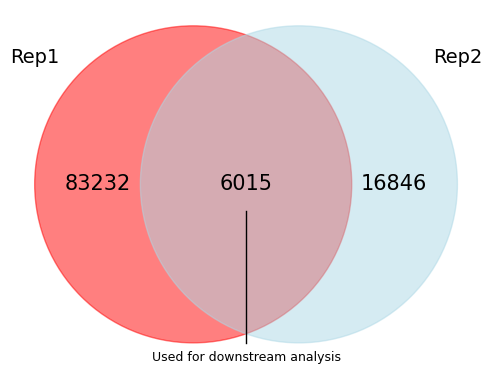

In [4]:
#venn diagram for S2C
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Define the file paths based on your directory structure
rep1_bed_file = '/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/rep1_peaks.bed'
rep2_bed_file = '/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/rep2_peaks.bed'
repr_bed_file = '/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/repr_peaks.bed'  # The reproducible/intersection file

# Function to count lines (peaks) in a BED file

def count_peaks(filename):
    with open(filename, 'r') as f:
        return sum(1 for line in f if line.strip())

rep1_count = count_peaks(rep1_bed_file)
rep2_count = count_peaks(rep2_bed_file)
repr_count = count_peaks(repr_bed_file)

only_rep1 = rep1_count - repr_count
only_rep2 = rep2_count - repr_count
shared = repr_count

# Plot manual Venn diagram using circles
fig, ax = plt.subplots(figsize=(6,6))
circle1 = Circle((0.4, 0.5), 0.3, color='red', alpha=0.5)
circle2 = Circle((0.6, 0.5), 0.3, color='lightblue', alpha=0.5)
ax.add_patch(circle1)
ax.add_patch(circle2)

# Numbers and labels
plt.text(0.22, 0.5, str(only_rep1), fontsize=15, ha='center', va='center')
plt.text(0.78, 0.5, str(only_rep2), fontsize=15, ha='center', va='center')
plt.text(0.5, 0.5, str(shared), fontsize=15, ha='center', va='center')
plt.text(0.1, 0.73, 'Rep1', fontsize=14, color='black', ha='center')
plt.text(0.9, 0.73, 'Rep2', fontsize=14, color='black', ha='center')

plt.plot([0.5, 0.5], [0.45, 0.2], 'k-', lw=1)  # Lower horizontal line
plt.text(0.5, 0.16, 'Used for downstream analysis', fontsize=9, ha='center', va='bottom')  # Centered below line, no angle

# plt.title('Peak Overlap Between Replicates')
ax.set_aspect('equal')
plt.axis('off')
plt.show()

Figure 8. Venn Diagram showing the RUNX1 peak reproducibility among the biological replicates. 

Major differences in the number of reproducible peaks were observed between the two biological replicates in my analysis and the author's. The number used for downstream analysis in my pipeline (6,015 reproducible peaks) is significantly larger than the original article's (3,466 reproduicble peaks). This finding is consistent with the higher gene overlap percentage seen in my analysis (Figure 4). The primary discrepancy is due to the less stringent statistical methods used in my pipeline, whereas the article employed a more stringent method. Additionally, the difference in the initial peak calling, such as mapping reads to a different version of the reference genome (hg38 versus hg19), also contributed to the variation in the number of reproducible peaks.

### Analyze the annotated peaks

In [5]:

# getting the gene id for enrichr analysis
df = pd.read_csv("/projectnb/bf528/students/nobma/projects/project3/project-3-taraobma/results/annotated_peaks.txt", sep="\t", dtype=str)

# Extract the gene names
genes = df["Gene Name"].dropna().unique()

print(f"Number of unique genes: {len(genes)}")

# Save as one-gene-per-line for Enrichr
with open("genes_for_enrichr.txt", "w") as f:
    for g in genes:
        f.write(g + "\n")

print("Saved gene list to: genes_for_enrichr.txt")

Number of unique genes: 5134
Saved gene list to: genes_for_enrichr.txt


![reactome_pathway](Reactome_Pathways_bar_graph.png)

Figure 9. Bar graph showing the reactome pathway enrichment results using Enrichr

The Reactome Pathway analysis shows that the differentially expressed and RUNX1-bound genes are most significantly enriched for VEGFR2 Mediated Vascular Permeability and HSF1-dependent Transactivation, followed by Cellular Response to Heat Stress. This finding is significant because RUNX1 is known to be involved in cancer progression, and these top hits suggest that RUNX1's regulatory role extends beyond basic transcription initiation (TSS binding) to control pathways essential for the tumor microenvironment, such as angiogenesis and stress response. The enrichment for Regulation of Localization of FOXO Transcription Factors and Formation of WDR5-containing Histone-Modifying Complexes directly ties RUNX1's binding to key TF signaling cascades and chromatin remodeling. This elucidates RUNX1's role as an architectural protein and suggests that RUNX1 doesn't just regulate transcription; it also coordinates the activity of major chromatin-modifying machinery to sculpt the genome's topology, thereby regulating downstream cancer-relevant pathways like VEGF signaling.